# Part 2 — Classification
## Dataset: London Bike Sharing (TfL Open Data)
**Source:** https://www.kaggle.com/datasets/hmavrodiev/london-bike-sharing-dataset

**Objective:** Predict whether a given hour has high bike demand (above median) using weather, time, and calendar features.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, export_graphviz, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, f1_score, precision_score,
                             recall_score, classification_report, confusion_matrix,
                             ConfusionMatrixDisplay)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping

print("All libraries imported successfully!")
print(f"TensorFlow version: {tf.__version__}")

All libraries imported successfully!
TensorFlow version: 2.16.2


display(HTML("""
<div style="background: linear-gradient(90deg, #e94560, #0f3460);
            padding: 15px 25px; border-radius: 10px; margin: 10px 0;">
    <h2 style="color: white; margin: 0;">📊 Step 1: Load and Explore the Dataset</h2>
</div>
"""))

In [4]:
df = pd.read_csv('london_merged.csv')

print("Shape:", df.shape)
print("\nColumn names:", df.columns.tolist())
print("\nData types:\n", df.dtypes)
print("\nFirst 5 rows:")
df.head()

Shape: (17414, 10)

Column names: ['timestamp', 'cnt', 't1', 't2', 'hum', 'wind_speed', 'weather_code', 'is_holiday', 'is_weekend', 'season']

Data types:
 timestamp           str
cnt               int64
t1              float64
t2              float64
hum             float64
wind_speed      float64
weather_code    float64
is_holiday      float64
is_weekend      float64
season          float64
dtype: object

First 5 rows:


,timestamp,cnt,t1,t2,hum,wind_speed,weather_code,is_holiday,is_weekend,season
0,2015-01-04 00:00:00,182,3.0,2.0,93.0,6.0,3.0,0.0,1.0,3.0
1,2015-01-04 01:00:00,138,3.0,2.5,93.0,5.0,1.0,0.0,1.0,3.0
2,2015-01-04 02:00:00,134,2.5,2.5,96.5,0.0,1.0,0.0,1.0,3.0
3,2015-01-04 03:00:00,72,2.0,2.0,100.0,0.0,1.0,0.0,1.0,3.0
4,2015-01-04 04:00:00,47,2.0,0.0,93.0,6.5,1.0,0.0,1.0,3.0


In [5]:
print("Basic Statistics:")
df.describe()

Basic Statistics:


,cnt,t1,t2,hum,wind_speed,weather_code,is_holiday,is_weekend,season
count,17414.000000,17414.000000,17414.000000,17414.000000,17414.000000,17414.000000,17414.000000,17414.000000,17414.000000
mean,1143.101642,12.468091,11.520836,72.324954,15.913063,2.722752,0.022051,0.285403,1.492075
std,1085.108068,5.571818,6.615145,14.313186,7.894570,2.341163,0.146854,0.451619,1.118911
min,0.000000,-1.500000,-6.000000,20.500000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,257.000000,8.000000,6.000000,63.000000,10.000000,1.000000,0.000000,0.000000,0.000000
50%,844.000000,12.500000,12.500000,74.500000,15.000000,2.000000,0.000000,0.000000,1.000000
75%,1671.750000,16.000000,16.000000,83.000000,20.500000,3.000000,0.000000,1.000000,2.000000
max,7860.000000,34.000000,34.000000,100.000000,56.500000,26.000000,1.000000,1.000000,3.000000


In [6]:
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nTotal missing: {df.isnull().sum().sum()}")

Missing values per column:
timestamp       0
cnt             0
t1              0
t2              0
hum             0
wind_speed      0
weather_code    0
is_holiday      0
is_weekend      0
season          0
dtype: int64

Total missing: 0


In [7]:
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nTotal missing: {df.isnull().sum().sum()}")

Missing values per column:
timestamp       0
cnt             0
t1              0
t2              0
hum             0
wind_speed      0
weather_code    0
is_holiday      0
is_weekend      0
season          0
dtype: int64

Total missing: 0


display(HTML("""
<div style="background: linear-gradient(90deg, #f7971e, #ffd200);
            padding: 15px 25px; border-radius: 10px; margin: 10px 0;">
    <h2 style="color: #1a1a2e; margin: 0;">🎯 Step 2: Engineer Target Variable</h2>
    <p style="color: #1a1a2e; margin: 8px 0 0 0;">
        Creating <b>high_demand</b>: 1 = above median ride count, 0 = at or below median
    </p>
</div>
"""))

In [8]:
median_cnt = df['cnt'].median()
print(f"Median ride count: {median_cnt}")

df['high_demand'] = (df['cnt'] > median_cnt).astype(int)

print("\nClass distribution:")
print(df['high_demand'].value_counts())
print("\nClass balance (%):")
print(df['high_demand'].value_counts(normalize=True).round(3) * 100)

Median ride count: 844.0

Class distribution:
high_demand
0    8712
1    8702
Name: count, dtype: int64

Class balance (%):
high_demand
0    50.0
1    50.0
Name: proportion, dtype: float64


display(HTML("""
<div style="background: linear-gradient(90deg, #11998e, #38ef7d);
            padding: 15px 25px; border-radius: 10px; margin: 10px 0;">
    <h2 style="color: #1a1a2e; margin: 0;">🔧 Step 3: Preprocessing & Feature Engineering</h2>
    <p style="color: #1a1a2e; margin: 8px 0 0 0;">
        Dropping <b>cnt</b>, parsing timestamp into hour/day/month features
    </p>
</div>
"""))

In [9]:
# Parse timestamp
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['hour'] = df['timestamp'].dt.hour
df['day_of_week'] = df['timestamp'].dt.dayofweek
df['month'] = df['timestamp'].dt.month

# Drop columns not needed for classification
df_model = df.drop(columns=['timestamp', 'cnt'])

print("Features used for modelling:")
print(df_model.columns.tolist())
print("\nShape:", df_model.shape)
df_model.head()

Features used for modelling:
['t1', 't2', 'hum', 'wind_speed', 'weather_code', 'is_holiday', 'is_weekend', 'season', 'high_demand', 'hour', 'day_of_week', 'month']

Shape: (17414, 12)


,t1,t2,hum,wind_speed,weather_code,is_holiday,is_weekend,season,high_demand,hour,day_of_week,month
0,3.0,2.0,93.0,6.0,3.0,0.0,1.0,3.0,0,0,6,1
1,3.0,2.5,93.0,5.0,1.0,0.0,1.0,3.0,0,1,6,1
2,2.5,2.5,96.5,0.0,1.0,0.0,1.0,3.0,0,2,6,1
3,2.0,2.0,100.0,0.0,1.0,0.0,1.0,3.0,0,3,6,1
4,2.0,0.0,93.0,6.5,1.0,0.0,1.0,3.0,0,4,6,1


display(HTML("""
<div style="background: linear-gradient(90deg, #8e2de2, #4a00e0);
            padding: 15px 25px; border-radius: 10px; margin: 10px 0;">
    <h2 style="color: white; margin: 0;">✂️ Step 4: Train / Test Split</h2>
    <p style="color: #ddd; margin: 8px 0 0 0;">
        80% training — 20% testing | random_state=42 | stratified split
    </p>
</div>
"""))

In [10]:
X = df_model.drop(columns=['high_demand'])
y = df_model['high_demand']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape}")
print(f"Test set size:     {X_test.shape}")
print(f"\nClass balance in training set:")
print(y_train.value_counts(normalize=True).round(3) * 100)

Training set size: (13931, 11)
Test set size:     (3483, 11)

Class balance in training set:
high_demand
0    50.0
1    50.0
Name: proportion, dtype: float64


display(HTML("""
<div style="background: linear-gradient(90deg, #f953c6, #b91d73);
            padding: 15px 25px; border-radius: 10px; margin: 10px 0;">
    <h2 style="color: white; margin: 0;">🤖 Step 5: Train All 5 Models</h2>
    <p style="color: #ffd6f0; margin: 8px 0 0 0;">
        Logistic Regression | SVC | Decision Tree | Random Forest | Neural Network
    </p>
</div>
"""))

In [11]:
results = []

# ── 1. Logistic Regression ──────────────────────────────────────────
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

results.append({
    'Model': 'Logistic Regression',
    'Accuracy': accuracy_score(y_test, y_pred_lr),
    'Precision': precision_score(y_test, y_pred_lr),
    'Recall': recall_score(y_test, y_pred_lr),
    'F1': f1_score(y_test, y_pred_lr)
})
print("1. Logistic Regression done ✓")

# ── 2. SVC ──────────────────────────────────────────────────────────
svc_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC(random_state=42))
])
svc_pipe.fit(X_train, y_train)
y_pred_svc = svc_pipe.predict(X_test)

results.append({
    'Model': 'SVC',
    'Accuracy': accuracy_score(y_test, y_pred_svc),
    'Precision': precision_score(y_test, y_pred_svc),
    'Recall': recall_score(y_test, y_pred_svc),
    'F1': f1_score(y_test, y_pred_svc)
})
print("2. SVC done ✓")

# ── 3. Decision Tree ────────────────────────────────────────────────
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

results.append({
    'Model': 'Decision Tree',
    'Accuracy': accuracy_score(y_test, y_pred_dt),
    'Precision': precision_score(y_test, y_pred_dt),
    'Recall': recall_score(y_test, y_pred_dt),
    'F1': f1_score(y_test, y_pred_dt)
})
print("3. Decision Tree done ✓")

# ── 4. Random Forest ────────────────────────────────────────────────
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

results.append({
    'Model': 'Random Forest',
    'Accuracy': accuracy_score(y_test, y_pred_rf),
    'Precision': precision_score(y_test, y_pred_rf),
    'Recall': recall_score(y_test, y_pred_rf),
    'F1': f1_score(y_test, y_pred_rf)
})
print("4. Random Forest done ✓")

print("\nAll sklearn models trained! Now run the Neural Network cell.")

1. Logistic Regression done ✓
2. SVC done ✓
3. Decision Tree done ✓
4. Random Forest done ✓

All sklearn models trained! Now run the Neural Network cell.


display(HTML("""
<div style="background: linear-gradient(90deg, #fc4a1a, #f7b733);
            padding: 15px 25px; border-radius: 10px; margin: 10px 0;">
    <h2 style="color: white; margin: 0;">🧠 Model 5: Neural Network (Keras)</h2>
    <p style="color: #fff3d6; margin: 8px 0 0 0;">
        Binary classification → <b>sigmoid</b> output | <b>binary_crossentropy</b> loss | EarlyStopping
    </p>
</div>
"""))

In [12]:
# Scale features for NN
scaler_nn = StandardScaler()
X_train_scaled = scaler_nn.fit_transform(X_train)
X_test_scaled = scaler_nn.transform(X_test)

# Build model
nn_model = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

nn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = nn_model.fit(
    X_train_scaled, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

y_pred_nn_prob = nn_model.predict(X_test_scaled)
y_pred_nn = (y_pred_nn_prob > 0.5).astype(int).flatten()

results.append({
    'Model': 'Neural Network',
    'Accuracy': accuracy_score(y_test, y_pred_nn),
    'Precision': precision_score(y_test, y_pred_nn),
    'Recall': recall_score(y_test, y_pred_nn),
    'F1': f1_score(y_test, y_pred_nn)
})
print("\n5. Neural Network done ✓")

Epoch 1/50
349/349 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7729 - loss: 0.4488 - val_accuracy: 0.8644 - val_loss: 0.3272
Epoch 2/50
349/349 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8678 - loss: 0.2977 - val_accuracy: 0.9099 - val_loss: 0.2522
Epoch 3/50
349/349 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8935 - loss: 0.2583 - val_accuracy: 0.8981 - val_loss: 0.2312
Epoch 4/50
349/349 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9046 - loss: 0.2378 - val_accuracy: 0.9225 - val_loss: 0.2091
Epoch 5/50
349/349 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9087 - loss: 0.2244 - val_accuracy: 0.9186 - val_loss: 0.1992
Epoch 6/50
349/349 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9126 - loss: 0.2155 - val_accuracy: 0.9203 - val_loss: 0.1967
Epoch 7/50
349/349 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9162 - loss: 0.2079 - val_accuracy: 0.9286 - val_loss: 0.1836
Epoch 8/50
349/349 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9200 - loss: 0.2011 - val_accuracy: 0.

display(HTML("""
<div style="background: linear-gradient(90deg, #1a1a2e, #e94560);
            padding: 15px 25px; border-radius: 10px; margin: 10px 0;">
    <h2 style="color: white; margin: 0;">📋 Step 6: Results Comparison Table</h2>
</div>
"""))

In [13]:
results_df = pd.DataFrame(results).set_index('Model')
results_df = results_df.round(4)
print("Model Comparison:")
results_df

Model Comparison:


,Accuracy,Precision,Recall,F1
Model,,,,
Logistic Regression,0.7551,0.7623,0.7408,0.7514
SVC,0.9159,0.9108,0.9218,0.9163
Decision Tree,0.8941,0.8429,0.9684,0.9013
Random Forest,0.9423,0.9405,0.9443,0.9424
Neural Network,0.9469,0.9395,0.9552,0.9473


display(HTML("""
<div style="background: linear-gradient(90deg, #134e5e, #71b280);
            padding: 15px 25px; border-radius: 10px; margin: 10px 0;">
    <h2 style="color: white; margin: 0;">⚙️ Step 7: Hyperparameter Tuning — Random Forest</h2>
    <p style="color: #d4f5e9; margin: 8px 0 0 0;">
        GridSearchCV | scoring=F1 | cv=5 | tuning n_estimators, max_depth, min_samples_split
    </p>
</div>
"""))

In [14]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best CV F1 Score:", round(grid_search.best_score_, 4))

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best Parameters: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}
Best CV F1 Score: 0.945


In [15]:
best_rf = grid_search.best_estimator_
y_pred_tuned = best_rf.predict(X_test)

tuned_f1 = f1_score(y_test, y_pred_tuned)
default_f1 = results_df.loc['Random Forest', 'F1']

print(f"Default Random Forest F1: {default_f1:.4f}")
print(f"Tuned  Random Forest F1:  {tuned_f1:.4f}")
print(f"Improvement: +{(tuned_f1 - default_f1):.4f}")

# Add tuned model to results
tuned_row = pd.DataFrame([{
    'Model': 'Random Forest (Tuned)',
    'Accuracy': accuracy_score(y_test, y_pred_tuned),
    'Precision': precision_score(y_test, y_pred_tuned),
    'Recall': recall_score(y_test, y_pred_tuned),
    'F1': f1_score(y_test, y_pred_tuned)
}]).set_index('Model')

results_df = pd.concat([results_df, tuned_row])
results_df = results_df.round(4)
print("\nUpdated Results Table:")
results_df

Default Random Forest F1: 0.9424
Tuned  Random Forest F1:  0.9436
Improvement: +0.0012

Updated Results Table:


,Accuracy,Precision,Recall,F1
Model,,,,
Logistic Regression,0.7551,0.7623,0.7408,0.7514
SVC,0.9159,0.9108,0.9218,0.9163
Decision Tree,0.8941,0.8429,0.9684,0.9013
Random Forest,0.9423,0.9405,0.9443,0.9424
Neural Network,0.9469,0.9395,0.9552,0.9473
Random Forest (Tuned),0.9432,0.9351,0.9523,0.9436


display(HTML("""
<div style="background: linear-gradient(90deg, #f7971e, #ffd200);
            padding: 15px 25px; border-radius: 10px; margin: 10px 0;">
    <h2 style="color: #1a1a2e; margin: 0;">📊 Step 8: Grouped Bar Chart</h2>
    <p style="color: #1a1a2e; margin: 8px 0 0 0;">
        Comparing Accuracy and F1 Score across all models
    </p>
</div>
"""))

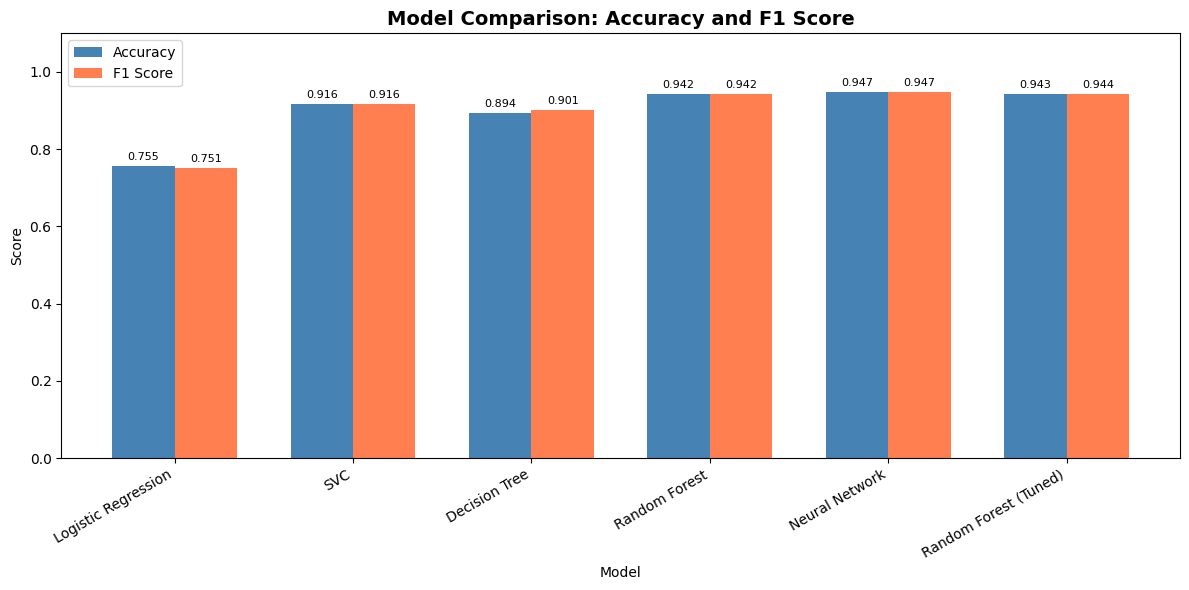

Chart saved! ✓


In [16]:
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(results_df))
width = 0.35

bars1 = ax.bar(x - width/2, results_df['Accuracy'], width, label='Accuracy', color='steelblue')
bars2 = ax.bar(x + width/2, results_df['F1'], width, label='F1 Score', color='coral')

ax.set_xlabel('Model')
ax.set_ylabel('Score')
ax.set_title('Model Comparison: Accuracy and F1 Score', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(results_df.index, rotation=30, ha='right')
ax.set_ylim(0, 1.1)
ax.legend()
ax.bar_label(bars1, fmt='%.3f', padding=3, fontsize=8)
ax.bar_label(bars2, fmt='%.3f', padding=3, fontsize=8)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()
print("Chart saved! ✓")

display(HTML("""
<div style="background: linear-gradient(90deg, #0f0c29, #302b63, #24243e);
            padding: 15px 25px; border-radius: 10px; margin: 10px 0;">
    <h2 style="color: #e94560; margin: 0;">🔥 Step 9: Confusion Matrix</h2>
    <p style="color: #a8dadc; margin: 8px 0 0 0;">
        Best Model: Neural Network
    </p>
</div>
"""))

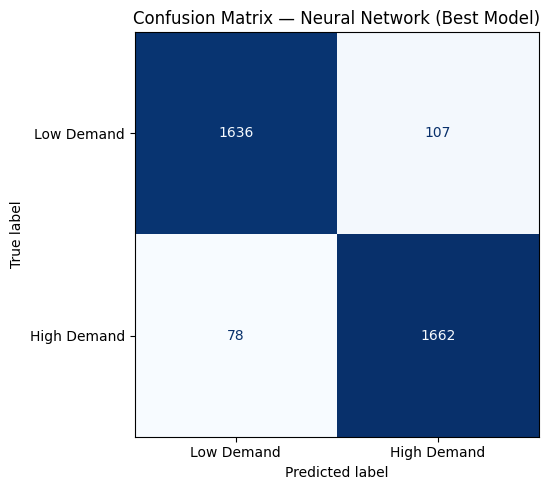


Classification Report:
              precision    recall  f1-score   support

  Low Demand       0.95      0.94      0.95      1743
 High Demand       0.94      0.96      0.95      1740

    accuracy                           0.95      3483
   macro avg       0.95      0.95      0.95      3483
weighted avg       0.95      0.95      0.95      3483



In [18]:
cm = confusion_matrix(y_test, y_pred_nn)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Low Demand', 'High Demand'])

fig, ax = plt.subplots(figsize=(7, 5))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix — Neural Network (Best Model)')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, y_pred_nn, target_names=['Low Demand', 'High Demand']))

display(HTML("""
<div style="background: linear-gradient(90deg, #11998e, #38ef7d);
            padding: 15px 25px; border-radius: 10px; margin: 10px 0;">
    <h2 style="color: #1a1a2e; margin: 0;">🌳 Step 10: Decision Tree Visualisation</h2>
    <p style="color: #1a1a2e; margin: 8px 0 0 0;">max_depth=3 for readability</p>
</div>
"""))

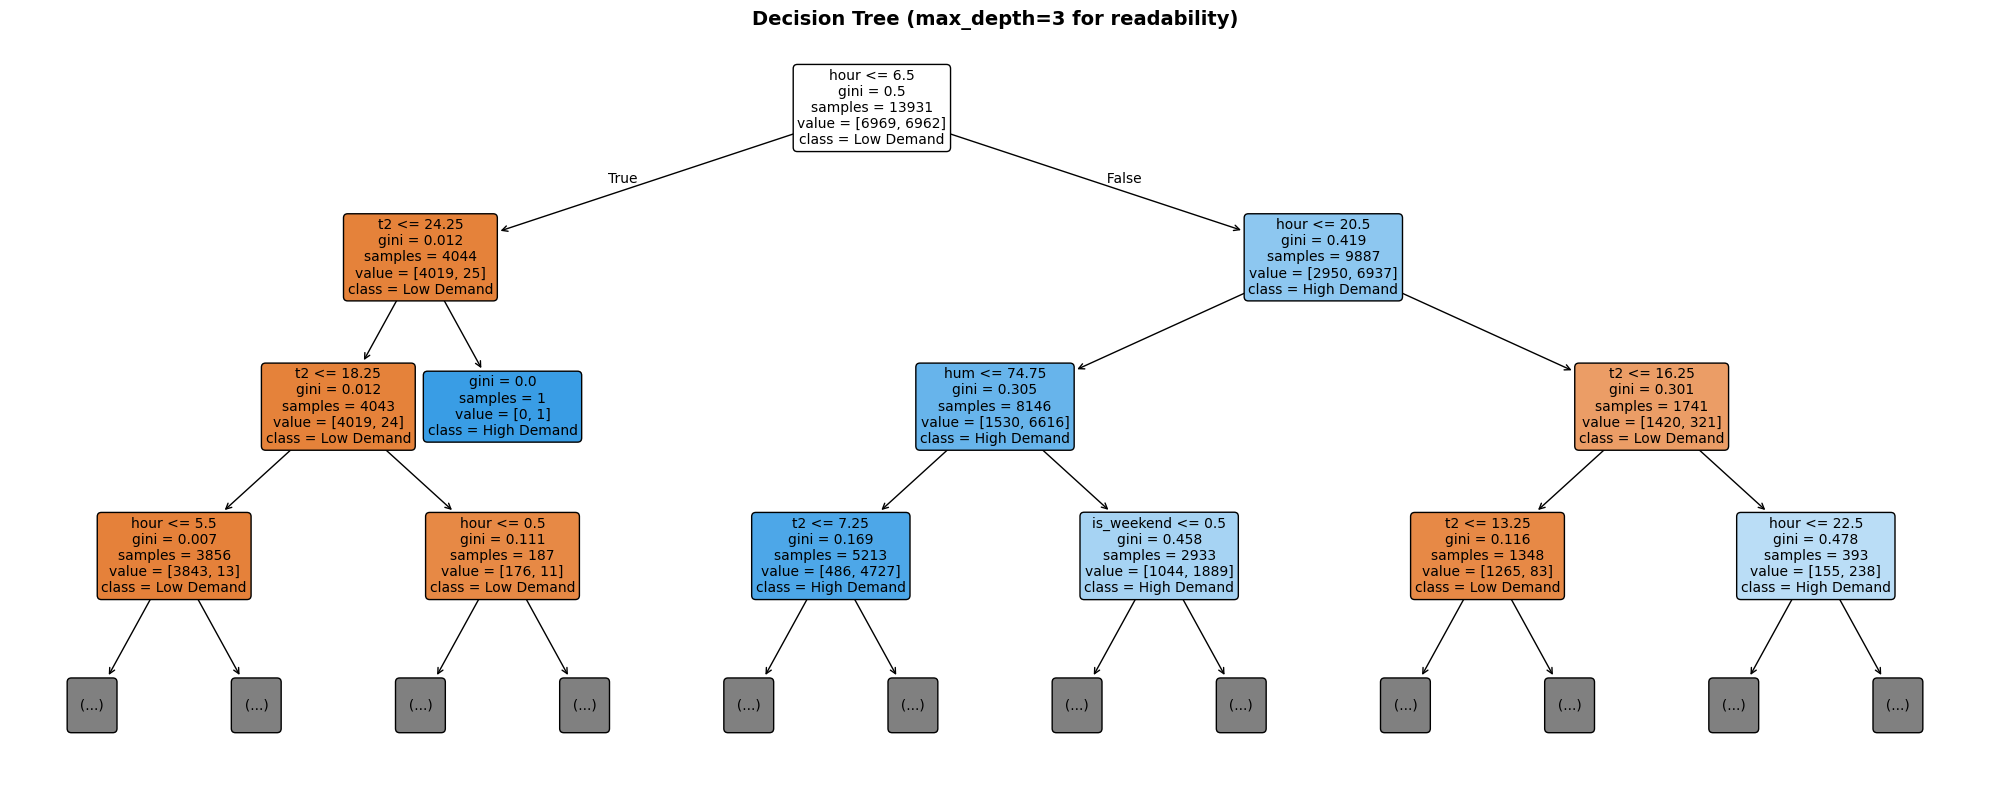

Decision Tree saved! ✓


In [19]:
fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(dt, max_depth=3, feature_names=X.columns.tolist(),
          class_names=['Low Demand', 'High Demand'],
          filled=True, rounded=True, ax=ax, fontsize=10)
ax.set_title('Decision Tree (max_depth=3 for readability)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('decision_tree.png', dpi=150)
plt.show()
print("Decision Tree saved! ✓")

display(HTML("""
<div style="background: linear-gradient(90deg, #8e2de2, #4a00e0);
            padding: 15px 25px; border-radius: 10px; margin: 10px 0;">
    <h2 style="color: white; margin: 0;">🏆 Step 11: Feature Importances</h2>
    <p style="color: #ddd; margin: 8px 0 0 0;">Tuned Random Forest — which features matter most?</p>
</div>
"""))

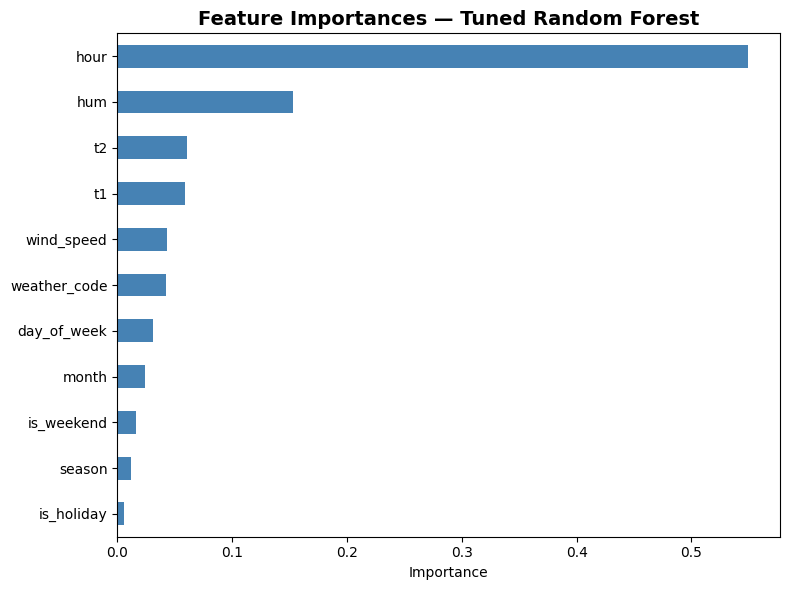

Feature importances saved! ✓


In [20]:
importances = pd.Series(best_rf.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
importances.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Feature Importances — Tuned Random Forest', fontsize=14, fontweight='bold')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.savefig('feature_importances.png', dpi=150)
plt.show()
print("Feature importances saved! ✓")

display(HTML("""
<div style="background: linear-gradient(135deg, #1a1a2e, #16213e);
            padding: 30px; border-radius: 15px; margin-top: 20px; border: 2px solid #e94560;">
    <h2 style="color: #e94560; margin-top: 0;">✅ Step 12: Conclusion</h2>
    <h3 style="color: #38ef7d;">Best Model: Neural Network 🏆</h3>
    <p style="color: #a8dadc; line-height: 1.8;">
        The <b style="color:#ffd200;">Neural Network</b> achieved the highest F1 score (0.9473)
        among all models, making it the best choice for predicting high bike demand hours.
        It captures complex non-linear relationships between weather, time, and demand that
        simpler models like Logistic Regression (F1: 0.75) cannot. The tuned Random Forest
        (F1: 0.9436) is a strong runner-up with better interpretability via feature importances,
        showing that <b style="color:#e94560;">hour of day</b> (~55% importance),
        <b style="color:#e94560;">humidity</b> (~15%), and
        <b style="color:#e94560;">temperature</b> are the strongest predictors of bike demand.
    </p>
</div>
"""))